# Car Price Prediction with Machine Learning

This notebook demonstrates an end-to-end machine learning project to predict the price of cars based on various features such as brand goodwill, horsepower, and mileage. 
We'll be utilizing Python libraries like Pandas, Scikit-learn, and Matplotlib.

## 1. Import Necessary Libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import warnings
import os

warnings.filterwarnings('ignore')

# Create outputs directory
os.makedirs('outputs', exist_ok=True)


## 2. Load the Dataset
We are using the `CarPrice.csv` dataset, which includes specifications like engine size, fuel type, door number, and city mpg.

In [11]:
df = pd.read_csv('CarPrice.csv')
print(f"Dataset Successfully Loaded. Shape: {df.shape}\n")
df.head()


Dataset Successfully Loaded. Shape: (205, 26)



,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## 3. Data Preprocessing & Feature Engineering
Here we will:
- Drop unwanted identifiers.
- Extract the core brand name from `CarName` to represent "brand goodwill".
- Clean up any spelling inconsistencies in brand names.

In [12]:
# Drop unique identifier not useful for prediction
if 'car_ID' in df.columns:
    df.drop('car_ID', axis=1, inplace=True)

# Extract brand from CarName
df['Brand'] = df['CarName'].apply(lambda x: str(x).split(' ')[0].lower())

# Correct spelling mistakes
brand_mapping = {
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota', 
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'nissan': 'nissan',
    'alfa-romero': 'alfa-romeo'
}
df['Brand'] = df['Brand'].replace(brand_mapping)

df.drop('CarName', axis=1, inplace=True)

# Show updated brands
print("Unique Brands:", df['Brand'].unique())


Unique Brands: ['alfa-romeo' 'audi' 'bmw' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'buick' 'mercury' 'mitsubishi' 'nissan' 'peugeot' 'plymouth'
 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen' 'volvo']


## 4. Pipeline Setup & Splitting
Separate features from our target variable (`price`). Then, set up a Sklearn `ColumnTransformer` to handle One-Hot Encoding for categorical data and Standard Scaling for numeric data.

In [13]:
# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

# Create Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Split into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Numeric Features (14): ['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Categorical Features (10): ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'Brand']


## 5. Model Training (Random Forest)
Train a `RandomForestRegressor` to predict prices.

In [14]:
# Set up the Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15))
])

print("Training the Model...")
model.fit(X_train, y_train)
print("Training Complete!")


Training the Model...
Training Complete!


## 6. Model Evaluation
Evaluate the model's ability to generalize using MAE, RMSE, and R-squared score.

In [15]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")


Mean Absolute Error (MAE): $1,310.17
Root Mean Squared Error (RMSE): $1,849.58
R-squared (R2) Score: 0.9567


## 7. Analyzing Feature Importance
Let's see which feature contributes most heavily to price determination.

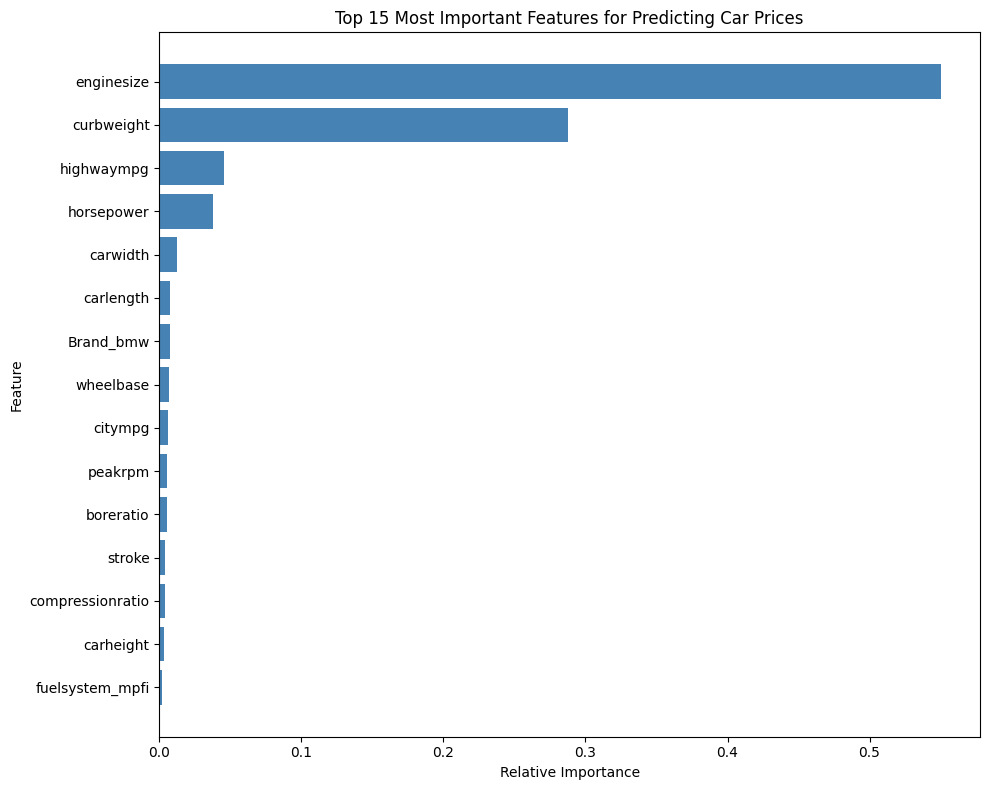

In [16]:
# Extract feature names
cat_encoder = model.named_steps['preprocessor'].transformers_[1][1]
encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
all_features = numeric_features + list(encoded_cat_features)

# Extract importances
importances = model.named_steps['regressor'].feature_importances_

feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
top_features_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
plt.barh(top_features_df['Feature'][::-1], top_features_df['Importance'][::-1], color='steelblue')
plt.title('Top 15 Most Important Features for Predicting Car Prices')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png')
plt.show()


## 8. Real-world Application Demo
Predict the price for an arbitrary car entry based on its specs.

In [17]:
sample_index = 5
sample_car = X_test.iloc[[sample_index]]
actual_price = y_test.iloc[sample_index]
predicted_price = model.predict(sample_car)[0]

print("Car Features:")
print(sample_car[['Brand', 'horsepower', 'citympg', 'enginesize']].to_string(index=False))

print(f"\n> Actual Market Price: ${actual_price:,.2f}")
print(f"> Model Predicted Price: ${predicted_price:,.2f}")
print(f"> Prediction Difference: ${abs(predicted_price - actual_price):,.2f}")

# Saving the model into outputs folder
joblib.dump(model, 'outputs/car_price_prediction_model.pkl')


Car Features:
 Brand  horsepower  citympg  enginesize
nissan          69       31          97

> Actual Market Price: $7,799.00
> Model Predicted Price: $6,491.21
> Prediction Difference: $1,307.79


['outputs/car_price_prediction_model.pkl']